# 08 — VQC Experiments
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Evaluate Variational Quantum Classifiers (VQC) for physiological stress classification
under LOSO cross-validation on WESAD and DREAMER.

## How VQC Works
Unlike QSVM which uses a fixed quantum kernel, VQC uses a **trainable parameterized
quantum circuit (PQC)** to learn the classification boundary directly:
1. Data is encoded via a feature map (angle encoding)
2. A variational ansatz with trainable parameters is applied
3. Parameters are optimized to minimize classification loss
4. Measurement outcomes determine the class prediction

## Experimental Grid
| Factor | Values |
|--------|--------|
| Ansatz | RealAmplitudes, EfficientSU2 |
| Entanglement | linear, circular |
| Repetitions | 1, 2 |
| PCA components | 3, 4 (WESAD) / 4, 6 (DREAMER) |
| Optimizer | COBYLA |

## Data Conditions (identical to QSVM)
- Stratified subsample: 150 windows per class per fold (train only)
- RobustScaler pre-PCA (best from QSVM experiments)
- MinMaxScaler(-pi, pi) post-PCA fixed
- Test set: all windows for held-out subject

## Datasets & Tasks
- WESAD binary (baseline vs stress)
- WESAD 3-class (baseline vs stress vs amusement)
- DREAMER binary EEG (low vs high arousal)

---


## 0. Configuration

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
from itertools import product

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

from qiskit.circuit.library import RealAmplitudes, EfficientSU2, ZZFeatureMap
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_algorithms.utils import algorithm_globals
from qiskit.primitives import StatevectorSampler
import logging

logging.getLogger('qiskit_machine_learning').setLevel(logging.ERROR)
logging.getLogger('qiskit_algorithms').setLevel(logging.ERROR)

warnings.filterwarnings('ignore')

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '08_vqc')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

ECG_FEATURE_PREFIXES   = ['ecg_']
RANDOM_STATE           = 42
N_SAMPLES_PER_CLASS    = 50

algorithm_globals.random_seed = RANDOM_STATE

# ── VQC experiment grid ───────────────────────────────────────────────────────
PCA_COMPONENTS_WESAD   = [3, 4]
PCA_COMPONENTS_DREAMER = [4, 6]
ANSATZ_NAMES           = ['RealAmplitudes', 'EfficientSU2']
ENTANGLEMENTS          = ['linear', 'circular']
REPS_LIST              = [1]
MAX_ITER               = 50    # COBYLA iterations

# Pre-PCA scaler fixed to RobustScaler (best from QSVM experiments)
# Post-PCA scaler fixed to MinMax(-pi, pi)

n_configs_wesad   = len(PCA_COMPONENTS_WESAD)   * len(ANSATZ_NAMES) * len(ENTANGLEMENTS) * len(REPS_LIST)
n_configs_dreamer = len(PCA_COMPONENTS_DREAMER)  * len(ANSATZ_NAMES) * len(ENTANGLEMENTS) * len(REPS_LIST)
n_configs_total   = n_configs_wesad * 2 + n_configs_dreamer

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  Ansatz             : {ANSATZ_NAMES}')
print(f'  Entanglements      : {ENTANGLEMENTS}')
print(f'  Reps               : {REPS_LIST}')
print(f'  PCA WESAD          : {PCA_COMPONENTS_WESAD}')
print(f'  PCA DREAMER        : {PCA_COMPONENTS_DREAMER}')
print(f'  Max COBYLA iters   : {MAX_ITER}')
print(f'  Subsample          : {N_SAMPLES_PER_CLASS} per class per fold')
print(f'  WESAD configs/task : {n_configs_wesad}')
print(f'  DREAMER configs    : {n_configs_dreamer}')
print(f'  Total configs      : {n_configs_total}')


Configuration ready.
  Ansatz             : ['RealAmplitudes', 'EfficientSU2']
  Entanglements      : ['linear', 'circular']
  Reps               : [1]
  PCA WESAD          : [3, 4]
  PCA DREAMER        : [4, 6]
  Max COBYLA iters   : 50
  Subsample          : 50 per class per fold
  WESAD configs/task : 8
  DREAMER configs    : 8
  Total configs      : 24


## 1. Load Datasets

In [2]:
df_wesad_bin = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_binary.csv'))
df_wesad_3cl = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_3class.csv'))
wesad_feat_cols = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'feature_columns.json')))

df_dreamer = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv'))
dreamer_all_feats = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'dreamer_feature_columns.json')))
dreamer_eeg_feats = [c for c in dreamer_all_feats
                     if not any(c.startswith(p) for p in ECG_FEATURE_PREFIXES)]

print('=== Datasets Loaded ===')
print(f'WESAD binary   : {df_wesad_bin.shape}  features={len(wesad_feat_cols)}')
print(f'WESAD 3-class  : {df_wesad_3cl.shape}')
print(f'DREAMER binary : {df_dreamer.shape}  EEG features={len(dreamer_eeg_feats)}')


=== Datasets Loaded ===
WESAD binary   : (883, 30)  features=26
WESAD 3-class  : (1049, 30)
DREAMER binary : (414, 146)  EEG features=134


## 2. Import Check

In [3]:
# Verify VQC imports work before running the full grid
try:
    from qiskit.circuit.library import RealAmplitudes, EfficientSU2, ZZFeatureMap
    from qiskit_machine_learning.algorithms import VQC
    from qiskit_algorithms.optimizers import COBYLA
    from qiskit.primitives import StatevectorSampler
    print('All VQC imports OK.')
except ImportError as e:
    print(f'Import error: {e}')
    print('Try: pip install qiskit-machine-learning qiskit-algorithms')

# Quick VQC smoke test
try:
    fm      = ZZFeatureMap(feature_dimension=3, reps=1)
    ansatz  = RealAmplitudes(num_qubits=3, reps=1, entanglement='linear')
    sampler = StatevectorSampler()
    opt     = COBYLA(maxiter=5)
    vqc     = VQC(feature_map=fm, ansatz=ansatz,
                  optimizer=opt, sampler=sampler)
    X_smoke = np.random.rand(10, 3)
    y_smoke = np.array([0,1,0,1,0,1,0,1,0,1])
    vqc.fit(X_smoke, y_smoke)
    preds = vqc.predict(X_smoke[:3])
    print(f'VQC smoke test passed. Predictions: {preds}')
except Exception as e:
    print(f'VQC smoke test failed: {e}')
    print('Check Qiskit version compatibility.')


All VQC imports OK.
VQC smoke test passed. Predictions: [1 0 0]


## 3. Utilities

In [4]:
def stratified_subsample(X, y, n_per_class, random_state=42):
    X_parts, y_parts = [], []
    rng = np.random.RandomState(random_state)
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        chosen = idx if len(idx) <= n_per_class \
                 else rng.choice(idx, size=n_per_class, replace=False)
        X_parts.append(X[chosen])
        y_parts.append(y[chosen])
    X_out = np.vstack(X_parts)
    y_out = np.concatenate(y_parts)
    perm  = rng.permutation(len(y_out))
    return X_out[perm], y_out[perm]


def compute_metrics(y_true, y_pred, average='macro'):
    return {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'f1'       : float(f1_score(y_true, y_pred,
                           average=average, zero_division=0)),
    }


def build_ansatz(name, n_qubits, reps, entanglement):
    if name == 'RealAmplitudes':
        return RealAmplitudes(
            num_qubits=n_qubits,
            reps=reps,
            entanglement=entanglement
        )
    elif name == 'EfficientSU2':
        return EfficientSU2(
            num_qubits=n_qubits,
            reps=reps,
            entanglement=entanglement
        )
    else:
        raise ValueError(f'Unknown ansatz: {name}')


def preprocess_fold(X_train, y_train, X_test, n_qubits, fold_i):
    """
    Full preprocessing pipeline for one fold:
    impute -> subsample -> RobustScale -> PCA -> MinMax(-pi, pi)
    All fitted on train only.
    """
    # Impute
    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    # Subsample
    X_tr, y_tr = stratified_subsample(
        X_train, y_train, N_SAMPLES_PER_CLASS,
        random_state=RANDOM_STATE + fold_i)

    # RobustScaler pre-PCA
    scaler = RobustScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_test)

    # PCA
    pca  = PCA(n_components=n_qubits, random_state=RANDOM_STATE)
    X_tr = pca.fit_transform(X_tr)
    X_te = pca.transform(X_te)

    # MinMax(-pi, pi) post-PCA
    mm   = MinMaxScaler(feature_range=(-np.pi, np.pi))
    X_tr = mm.fit_transform(X_tr)
    X_te = mm.transform(X_te)

    return X_tr, y_tr, X_te


print('Utilities defined.')


Utilities defined.


## 4. VQC LOSO Pipeline

In [5]:
def run_vqc_loso(df, feature_cols, label_col, subject_col,
                 ansatz_name, n_qubits, reps, entanglement,
                 task_name, average='macro',
                 n_per_class=N_SAMPLES_PER_CLASS):
    """
    LOSO cross-validation for one VQC configuration.
    """
    subjects = sorted(df[subject_col].unique())
    classes  = sorted(df[label_col].unique())
    n_cls    = len(classes)
    n_classes = len(classes)

    fold_rows = []
    cm_accum  = np.zeros((n_cls, n_cls), dtype=int)

    config_str = (f'{ansatz_name}_n{n_qubits}_'
                  f'r{reps}_{entanglement}')

    for fold_i, test_sid in enumerate(subjects):
        train_mask = df[subject_col] != test_sid
        test_mask  = df[subject_col] == test_sid

        X_train = df.loc[train_mask, feature_cols].values.astype(float)
        y_train = df.loc[train_mask, label_col].values
        X_test  = df.loc[test_mask,  feature_cols].values.astype(float)
        y_test  = df.loc[test_mask,  label_col].values

        try:
            # Preprocess
            X_tr, y_tr, X_te = preprocess_fold(
                X_train, y_train, X_test, n_qubits, fold_i)

            # Build VQC
            fm      = ZZFeatureMap(feature_dimension=n_qubits, reps=1)
            ansatz  = build_ansatz(ansatz_name, n_qubits, reps, entanglement)
            sampler = StatevectorSampler()
            opt     = COBYLA(maxiter=MAX_ITER)

            vqc = VQC(
                feature_map = fm,
                ansatz      = ansatz,
                optimizer   = opt,
                sampler     = sampler,
            )

            # Train
            t0 = time.time()
            vqc.fit(X_tr, y_tr)
            train_time = time.time() - t0

            # Predict
            t1     = time.time()
            y_pred = vqc.predict(X_te)
            test_time = time.time() - t1

            metrics = compute_metrics(y_test, y_pred, average=average)
            cm      = confusion_matrix(y_test, y_pred, labels=classes)
            cm_accum += cm
            status  = 'ok'

        except Exception as e:
            metrics    = {'accuracy':np.nan,'precision':np.nan,
                          'recall':np.nan,'f1':np.nan}
            train_time = np.nan
            test_time  = np.nan
            status     = f'error: {str(e)[:80]}'

        fold_rows.append({
            'task'        : task_name,
            'ansatz'      : ansatz_name,
            'n_qubits'    : n_qubits,
            'reps'        : reps,
            'entanglement': entanglement,
            'config'      : config_str,
            'fold'        : fold_i + 1,
            'test_subject': int(test_sid),
            'train_time'  : round(train_time, 2) if not np.isnan(train_time) else np.nan,
            'test_time'   : round(test_time, 4)  if not np.isnan(test_time)  else np.nan,
            'status'      : status,
            **metrics
        })

    return pd.DataFrame(fold_rows), cm_accum


def run_vqc_grid(df, feature_cols, label_col, subject_col,
                 task_name, pca_components, average='macro'):
    """
    Run the full VQC grid across all configurations.
    """
    all_rows = []
    best_f1  = -1
    best_cm  = None
    best_cfg = None

    configs = list(product(ANSATZ_NAMES, pca_components,
                           REPS_LIST, ENTANGLEMENTS))
    print(f'Total configurations: {len(configs)}')
    print(f'Task: {task_name}\n')

    for i, (ansatz_name, n_q, reps, ent) in enumerate(configs):
        cfg_str = (f'{ansatz_name} | n_qubits={n_q} | '
                   f'reps={reps} | {ent}')
        print(f'[{i+1:2d}/{len(configs)}] {cfg_str}')

        t_start = time.time()
        fold_df, cm = run_vqc_loso(
            df=df, feature_cols=feature_cols,
            label_col=label_col, subject_col=subject_col,
            ansatz_name=ansatz_name, n_qubits=n_q,
            reps=reps, entanglement=ent,
            task_name=task_name, average=average
        )
        elapsed = time.time() - t_start

        mean_f1  = fold_df['f1'].mean()
        mean_acc = fold_df['accuracy'].mean()
        all_rows.append(fold_df)

        if mean_f1 > best_f1:
            best_f1  = mean_f1
            best_cm  = cm
            best_cfg = cfg_str

        print(f'         mean_acc={mean_acc:.4f}  '
              f'mean_f1={mean_f1:.4f}  '
              f'total_time={elapsed:.0f}s')

    results_df = pd.concat(all_rows, ignore_index=True)
    print(f'\nBest config : {best_cfg}')
    print(f'Best mean F1: {best_f1:.4f}')
    return results_df, best_cm, best_cfg


print('VQC LOSO pipeline defined.')


VQC LOSO pipeline defined.


## 5. WESAD Binary Task
> Expect 2-4 hours depending on hardware.

In [6]:
print('Starting WESAD binary...')
results_wb, best_cm_wb, best_cfg_wb = run_vqc_grid(
    df             = df_wesad_bin,
    feature_cols   = wesad_feat_cols,
    label_col      = 'label_encoded',
    subject_col    = 'subject_id',
    task_name      = 'WESAD_binary_VQC',
    pca_components = PCA_COMPONENTS_WESAD,
)
 

Starting WESAD binary...
Total configurations: 8
Task: WESAD_binary_VQC

[ 1/8] RealAmplitudes | n_qubits=3 | reps=1 | linear
         mean_acc=0.4997  mean_f1=0.4826  total_time=1069s
[ 2/8] RealAmplitudes | n_qubits=3 | reps=1 | circular
         mean_acc=0.4805  mean_f1=0.4692  total_time=1106s
[ 3/8] RealAmplitudes | n_qubits=4 | reps=1 | linear
         mean_acc=0.5475  mean_f1=0.5335  total_time=1257s
[ 4/8] RealAmplitudes | n_qubits=4 | reps=1 | circular
         mean_acc=0.5103  mean_f1=0.4962  total_time=1238s
[ 5/8] EfficientSU2 | n_qubits=3 | reps=1 | linear
         mean_acc=0.5006  mean_f1=0.4866  total_time=614s
[ 6/8] EfficientSU2 | n_qubits=3 | reps=1 | circular
         mean_acc=0.5195  mean_f1=0.5049  total_time=613s
[ 7/8] EfficientSU2 | n_qubits=4 | reps=1 | linear
         mean_acc=0.5139  mean_f1=0.5021  total_time=730s
[ 8/8] EfficientSU2 | n_qubits=4 | reps=1 | circular
         mean_acc=0.5168  mean_f1=0.4958  total_time=730s

Best config : RealAmplitudes | n_q

## 6. WESAD 3-Class Task

In [7]:
print('Starting WESAD 3-class...')
results_w3, best_cm_w3, best_cfg_w3 = run_vqc_grid(
    df             = df_wesad_3cl,
    feature_cols   = wesad_feat_cols,
    label_col      = 'label_encoded',
    subject_col    = 'subject_id',
    task_name      = 'WESAD_3class_VQC',
    pca_components = PCA_COMPONENTS_WESAD,
    average        = 'macro',
)


Starting WESAD 3-class...
Total configurations: 8
Task: WESAD_3class_VQC

[ 1/8] RealAmplitudes | n_qubits=3 | reps=1 | linear
         mean_acc=0.4554  mean_f1=0.3215  total_time=806s
[ 2/8] RealAmplitudes | n_qubits=3 | reps=1 | circular
         mean_acc=0.4491  mean_f1=0.3192  total_time=803s
[ 3/8] RealAmplitudes | n_qubits=4 | reps=1 | linear
         mean_acc=0.4181  mean_f1=0.2963  total_time=349s
[ 4/8] RealAmplitudes | n_qubits=4 | reps=1 | circular
         mean_acc=0.4098  mean_f1=0.2895  total_time=369s
[ 5/8] EfficientSU2 | n_qubits=3 | reps=1 | linear
         mean_acc=0.4204  mean_f1=0.2919  total_time=333s
[ 6/8] EfficientSU2 | n_qubits=3 | reps=1 | circular
         mean_acc=0.4540  mean_f1=0.3231  total_time=334s
[ 7/8] EfficientSU2 | n_qubits=4 | reps=1 | linear
         mean_acc=0.4442  mean_f1=0.3055  total_time=389s
[ 8/8] EfficientSU2 | n_qubits=4 | reps=1 | circular
         mean_acc=0.4105  mean_f1=0.2879  total_time=413s

Best config : EfficientSU2 | n_qubits

## 7. DREAMER Binary EEG Task

In [8]:
print('Starting DREAMER binary EEG...')
results_db, best_cm_db, best_cfg_db = run_vqc_grid(
    df             = df_dreamer,
    feature_cols   = dreamer_eeg_feats,
    label_col      = 'arousal_binary',
    subject_col    = 'subject_id',
    task_name      = 'DREAMER_binary_EEG_VQC',
    pca_components = PCA_COMPONENTS_DREAMER,
    average        = 'macro',
)


Starting DREAMER binary EEG...
Total configurations: 8
Task: DREAMER_binary_EEG_VQC

[ 1/8] RealAmplitudes | n_qubits=4 | reps=1 | linear
         mean_acc=0.4710  mean_f1=0.3965  total_time=366s
[ 2/8] RealAmplitudes | n_qubits=4 | reps=1 | circular
         mean_acc=0.5242  mean_f1=0.4285  total_time=675s
[ 3/8] RealAmplitudes | n_qubits=6 | reps=1 | linear
         mean_acc=0.4976  mean_f1=0.4388  total_time=1118s
[ 4/8] RealAmplitudes | n_qubits=6 | reps=1 | circular
         mean_acc=0.4831  mean_f1=0.4400  total_time=511s
[ 5/8] EfficientSU2 | n_qubits=4 | reps=1 | linear
         mean_acc=0.5024  mean_f1=0.4126  total_time=416s
[ 6/8] EfficientSU2 | n_qubits=4 | reps=1 | circular
         mean_acc=0.5024  mean_f1=0.4041  total_time=435s
[ 7/8] EfficientSU2 | n_qubits=6 | reps=1 | linear
         mean_acc=0.5483  mean_f1=0.4869  total_time=582s
[ 8/8] EfficientSU2 | n_qubits=6 | reps=1 | circular
         mean_acc=0.5217  mean_f1=0.4637  total_time=579s

Best config : EfficientSU

## 8. Results Summary

In [9]:
all_results = pd.concat([results_wb, results_w3, results_db], ignore_index=True)

# Best config per task
print('=== BEST VQC CONFIGURATION PER TASK ===')
best_per_task = (
    all_results
    .groupby(['task','config','ansatz','n_qubits','reps','entanglement'])
    .agg(f1_mean=('f1','mean'), f1_std=('f1','std'),
         acc_mean=('accuracy','mean'),
         train_time_mean=('train_time','mean'))
    .reset_index()
    .sort_values(['task','f1_mean'], ascending=[True, False])
)

for task in best_per_task['task'].unique():
    print(f'\n  {task}:')
    top = best_per_task[best_per_task['task']==task].head(3)
    print(top[['config','f1_mean','f1_std','acc_mean',
                'train_time_mean']].round(4).to_string(index=False))

# Summary by ansatz
print('\n=== VQC SUMMARY BY ANSATZ ===')
ansatz_summary = (
    all_results
    .groupby(['task','ansatz'])
    .agg(f1_mean=('f1','mean'), f1_std=('f1','std'),
         acc_mean=('accuracy','mean'),
         train_time_mean=('train_time','mean'))
    .round(4)
    .reset_index()
)
print(ansatz_summary.to_string(index=False))

# Save
p = os.path.join(OUTPUT_DATA_DIR, 'vqc_all_results_cobyla.csv')
all_results.to_csv(p, index=False)
print(f'\nSaved: {p}')

p2 = os.path.join(OUTPUT_DATA_DIR, 'vqc_best_per_task_cobyla.csv')
best_per_task.to_csv(p2, index=False)
print(f'Saved: {p2}')


=== BEST VQC CONFIGURATION PER TASK ===

  DREAMER_binary_EEG_VQC:
                       config  f1_mean  f1_std  acc_mean  train_time_mean
    EfficientSU2_n6_r1_linear   0.4869  0.1258    0.5483          25.1822
  EfficientSU2_n6_r1_circular   0.4637  0.1226    0.5217          25.0504
RealAmplitudes_n6_r1_circular   0.4400  0.1074    0.4831          22.0783

  WESAD_3class_VQC:
                       config  f1_mean  f1_std  acc_mean  train_time_mean
  EfficientSU2_n3_r1_circular   0.3231  0.0476    0.4540          22.0193
  RealAmplitudes_n3_r1_linear   0.3215  0.0623    0.4554          53.1740
RealAmplitudes_n3_r1_circular   0.3192  0.0548    0.4491          53.0067

  WESAD_binary_VQC:
                     config  f1_mean  f1_std  acc_mean  train_time_mean
RealAmplitudes_n4_r1_linear   0.5335  0.0853    0.5475          82.8107
EfficientSU2_n3_r1_circular   0.5049  0.0883    0.5195          40.3413
  EfficientSU2_n4_r1_linear   0.5021  0.0700    0.5139          48.0900

=== VQC SU

## 9. Plots

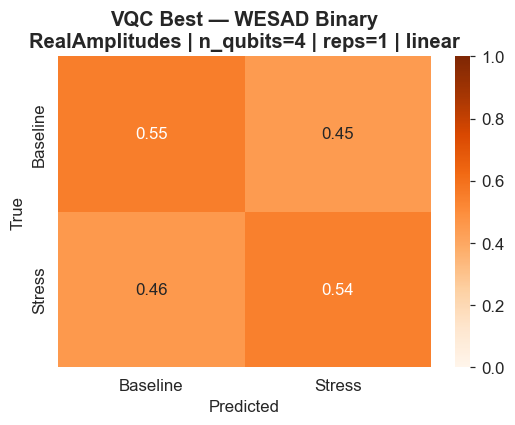

Saved: ..\results\plots\08_vqc\cm_vqc_wesad_binary_best_cobyla.png


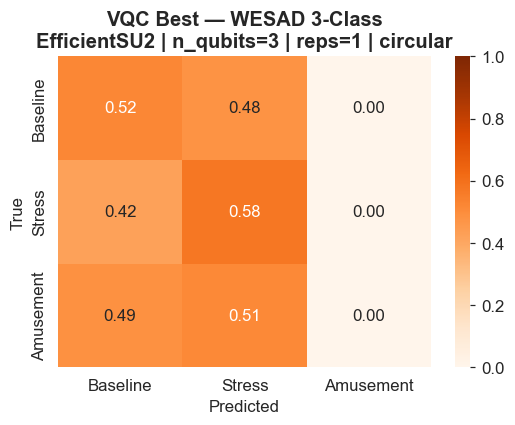

Saved: ..\results\plots\08_vqc\cm_vqc_wesad_3class_best_cobyla.png


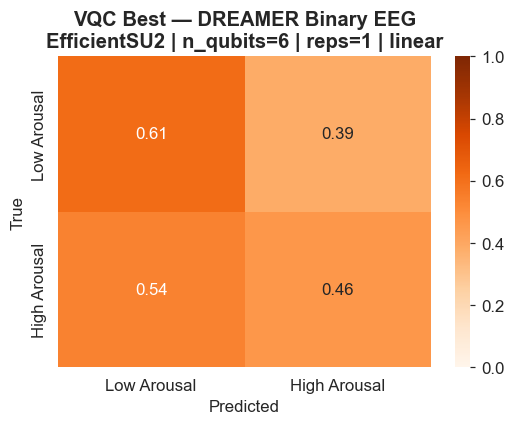

Saved: ..\results\plots\08_vqc\cm_vqc_dreamer_binary_best_cobyla.png


In [10]:
def plot_cm(cm, class_names, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1, annot_kws={'size':11})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_cm(best_cm_wb, ['Baseline','Stress'],
        f'VQC Best — WESAD Binary\n{best_cfg_wb}',
        os.path.join(PLOTS_DIR, 'cm_vqc_wesad_binary_best_cobyla.png'))

plot_cm(best_cm_w3, ['Baseline','Stress','Amusement'],
        f'VQC Best — WESAD 3-Class\n{best_cfg_w3}',
        os.path.join(PLOTS_DIR, 'cm_vqc_wesad_3class_best_cobyla.png'))

plot_cm(best_cm_db, ['Low Arousal','High Arousal'],
        f'VQC Best — DREAMER Binary EEG\n{best_cfg_db}',
        os.path.join(PLOTS_DIR, 'cm_vqc_dreamer_binary_best_cobyla.png'))


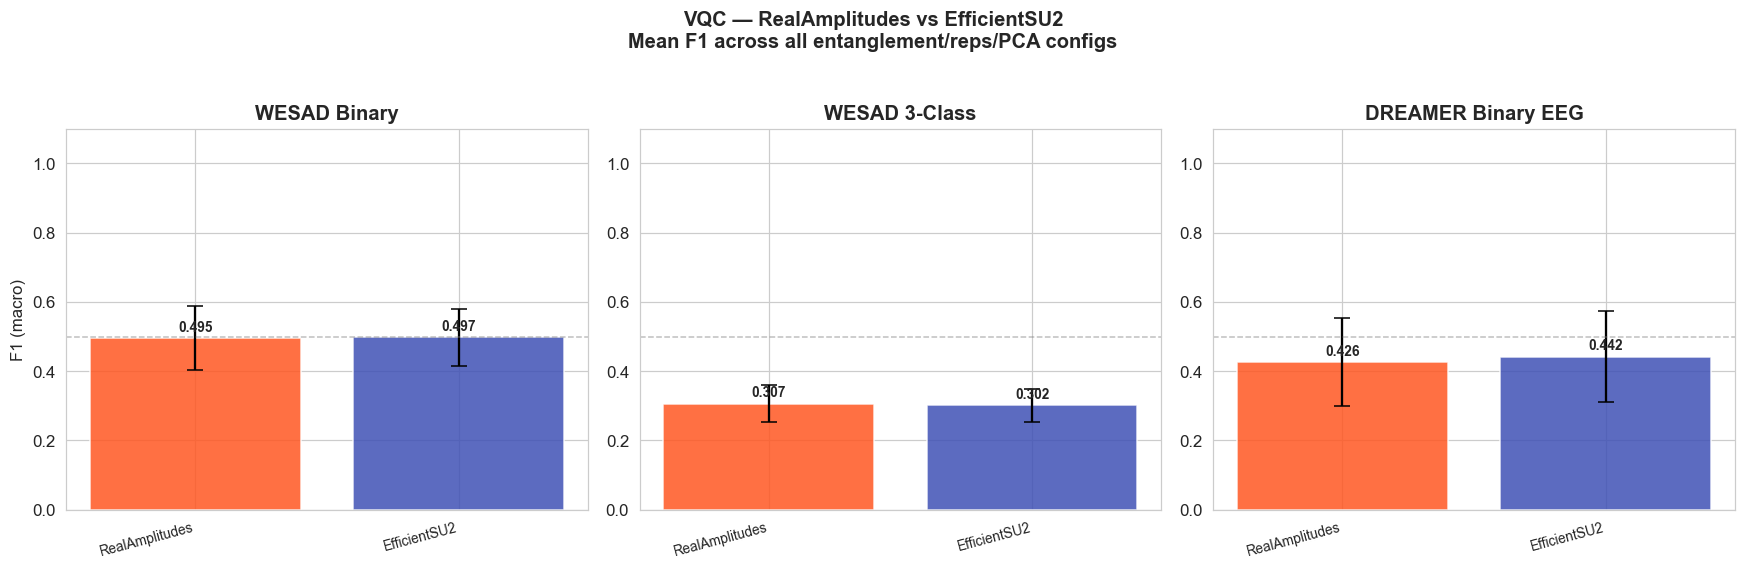

Saved: ..\results\plots\08_vqc\vqc_ansatz_comparison_cobyla.png


In [11]:
# F1 comparison: RealAmplitudes vs EfficientSU2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ansatz_colors = {'RealAmplitudes': '#FF5722', 'EfficientSU2': '#3F51B5'}

for ax, (task_key, task_label) in zip(axes, [
        ('WESAD_binary_VQC',      'WESAD Binary'),
        ('WESAD_3class_VQC',      'WESAD 3-Class'),
        ('DREAMER_binary_EEG_VQC','DREAMER Binary EEG')]):

    td = all_results[all_results['task']==task_key]
    for j, ansatz in enumerate(ANSATZ_NAMES):
        vals = td[td['ansatz']==ansatz]['f1']
        if len(vals) == 0:
            continue
        ax.bar(j, vals.mean(), color=ansatz_colors[ansatz],
               alpha=0.85, yerr=vals.std(), capsize=5)
        ax.text(j, vals.mean()+0.02, f'{vals.mean():.3f}',
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)' if ax == axes[0] else '')
    ax.set_xticks(range(len(ANSATZ_NAMES)))
    ax.set_xticklabels(ANSATZ_NAMES, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5)

plt.suptitle('VQC — RealAmplitudes vs EfficientSU2\n'
             'Mean F1 across all entanglement/reps/PCA configs',
             fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'vqc_ansatz_comparison_cobyla.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


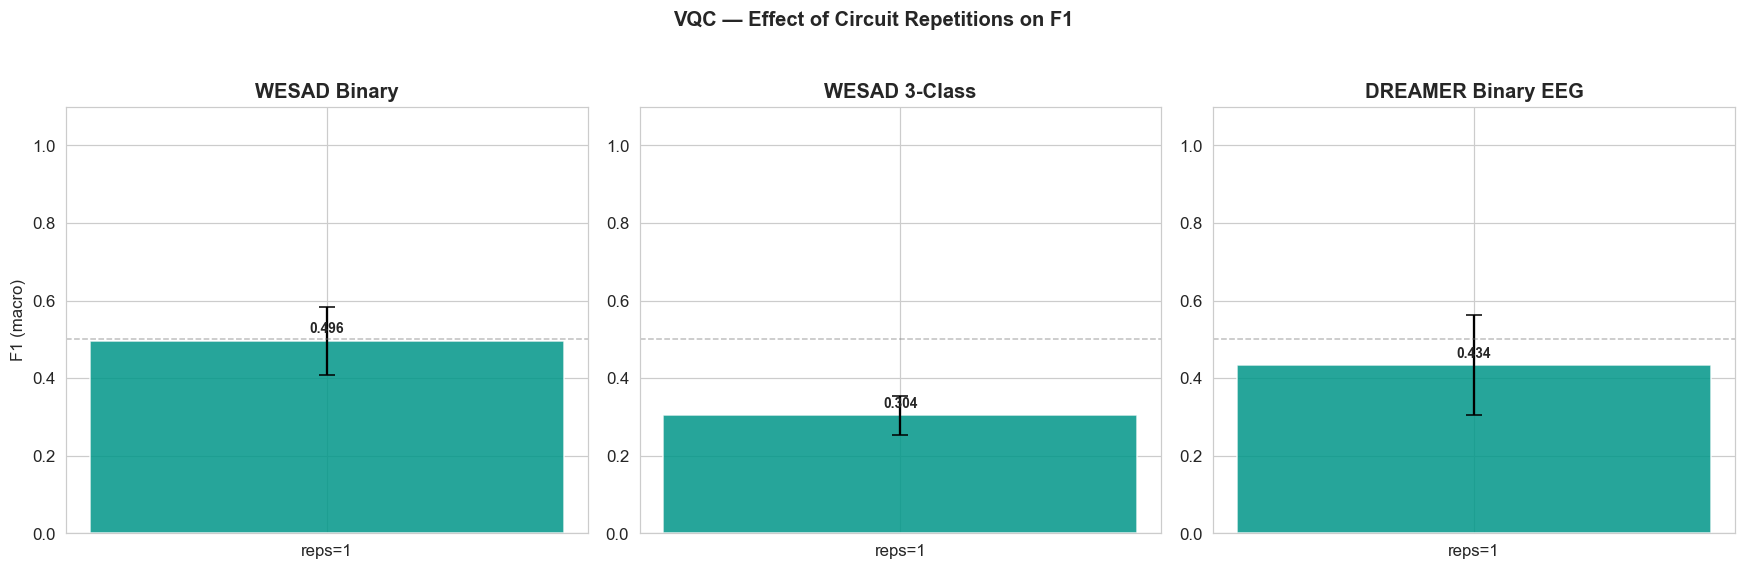

Saved: ..\results\plots\08_vqc\vqc_reps_comparison_cobyla.png


In [12]:
# Effect of reps on F1
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
reps_colors = {1: '#009688', 2: '#E91E63'}

for ax, (task_key, task_label) in zip(axes, [
        ('WESAD_binary_VQC',      'WESAD Binary'),
        ('WESAD_3class_VQC',      'WESAD 3-Class'),
        ('DREAMER_binary_EEG_VQC','DREAMER Binary EEG')]):

    td = all_results[all_results['task']==task_key]
    for j, r in enumerate(REPS_LIST):
        vals = td[td['reps']==r]['f1']
        if len(vals) == 0:
            continue
        ax.bar(j, vals.mean(), color=reps_colors.get(r,'gray'),
               alpha=0.85, yerr=vals.std(), capsize=5,
               label=f'reps={r}')
        ax.text(j, vals.mean()+0.02, f'{vals.mean():.3f}',
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)' if ax == axes[0] else '')
    ax.set_xticks(range(len(REPS_LIST)))
    ax.set_xticklabels([f'reps={r}' for r in REPS_LIST])
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5)

plt.suptitle('VQC — Effect of Circuit Repetitions on F1',
             fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'vqc_reps_comparison_cobyla.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


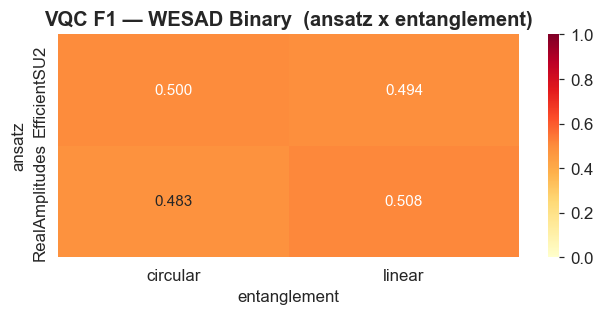

Saved: ..\results\plots\08_vqc\vqc_heatmap_wesad_binary_vqc_cobyla.png


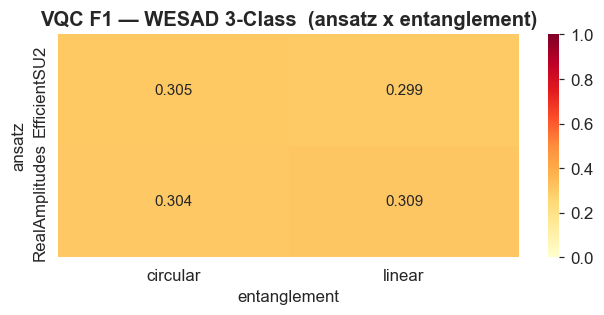

Saved: ..\results\plots\08_vqc\vqc_heatmap_wesad_3class_vqc_cobyla.png


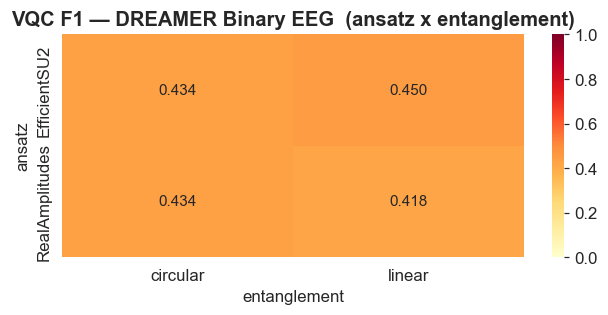

Saved: ..\results\plots\08_vqc\vqc_heatmap_dreamer_binary_eeg_vqc_cobyla.png


In [13]:
# F1 heatmap: ansatz x entanglement
for task_key, task_label in [
        ('WESAD_binary_VQC',      'WESAD Binary'),
        ('WESAD_3class_VQC',      'WESAD 3-Class'),
        ('DREAMER_binary_EEG_VQC','DREAMER Binary EEG')]:

    td = all_results[all_results['task']==task_key]
    if len(td) == 0:
        continue
    pivot = td.groupby(['ansatz','entanglement'])['f1'].mean().unstack()
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                ax=ax, vmin=0, vmax=1, annot_kws={'size':10})
    ax.set_title(f'VQC F1 — {task_label}  (ansatz x entanglement)',
                 fontweight='bold')
    plt.tight_layout()
    p = os.path.join(PLOTS_DIR,
                     f'vqc_heatmap_{task_key.lower()}_cobyla.png')
    plt.savefig(p, bbox_inches='tight'); plt.show()
    print(f'Saved: {p}')


## 10. Stress/Amusement Overlap Analysis (WESAD 3-Class)

In [14]:
print('=== VQC Best Config: Stress/Amusement Confusion ===')
cm = best_cm_w3
total_stress = cm[1, :].sum()
total_amuse  = cm[2, :].sum()
s_a = cm[1, 2] / total_stress if total_stress > 0 else 0
a_s = cm[2, 1] / total_amuse  if total_amuse  > 0 else 0
print(f'  Stress -> Amusement : {cm[1,2]}/{total_stress} ({s_a*100:.1f}%)')
print(f'  Amusement -> Stress : {cm[2,1]}/{total_amuse}  ({a_s*100:.1f}%)')

# Append to combined overlap file
overlap_path = os.path.join(OUTPUT_DATA_DIR, 'overlap_classical_vs_qsvm.csv')
vqc_overlap  = pd.DataFrame([{
    'model'                  : f'VQC-COBYLA ({best_cfg_w3})',
    'stress->amusement_rate' : round(s_a, 4),
    'amusement->stress_rate' : round(a_s, 4),
}])

if os.path.exists(overlap_path):
    df_prev = pd.read_csv(overlap_path)
    combined = pd.concat([df_prev, vqc_overlap], ignore_index=True)
else:
    combined = vqc_overlap

p = os.path.join(OUTPUT_DATA_DIR, 'overlap_all_models.csv')
combined.to_csv(p, index=False)
print('\n=== Full Overlap Comparison (all models) ===')
print(combined.to_string(index=False))
print(f'\nSaved: {p}')


=== VQC Best Config: Stress/Amusement Confusion ===
  Stress -> Amusement : 0/313 (0.0%)
  Amusement -> Stress : 85/166  (51.2%)

=== Full Overlap Comparison (all models) ===
                                                     model  stress->amusement_rate  amusement->stress_rate
                                       Logistic Regression                  0.1150                  0.0482
                                                 SVM (RBF)                  0.1246                  0.0602
                                             Random Forest                  0.0511                  0.1145
 QSVM (ZZFeatureMap | n_qubits=3 | reps=2 | full | robust)                  0.2684                  0.2229
VQC-COBYLA (EfficientSU2 | n_qubits=3 | reps=1 | circular)                  0.0000                  0.5120

Saved: ..\results\output_data\overlap_all_models.csv


## 11. Summary Log

In [15]:
best_results = {}
for task in all_results['task'].unique():
    td       = all_results[all_results['task']==task]
    best_row = td.groupby('config')['f1'].mean().idxmax()
    best_data= td[td['config']==best_row]
    best_results[task] = {
        'best_config'    : best_row,
        'f1_mean'        : round(best_data['f1'].mean(), 4),
        'f1_std'         : round(best_data['f1'].std(),  4),
        'accuracy_mean'  : round(best_data['accuracy'].mean(), 4),
        'train_time_mean': round(best_data['train_time'].mean(), 2),
    }

summary = {
    'notebook'    : '08_vqc_experiments_cobyla',
    'timestamp'   : datetime.now().isoformat(),
    'experiment_grid': {
        'ansatz'               : ANSATZ_NAMES,
        'pca_components_wesad' : PCA_COMPONENTS_WESAD,
        'pca_components_dreamer': PCA_COMPONENTS_DREAMER,
        'reps'                 : REPS_LIST,
        'entanglements'        : ENTANGLEMENTS,
        'optimizer'            : f'COBYLA(maxiter={MAX_ITER})',
        'pre_pca_scaler'       : 'RobustScaler (fixed, best from QSVM)',
        'post_pca_scaler'      : 'MinMaxScaler(-pi, pi) fixed',
    },
    'subsampling' : {'n_per_class': N_SAMPLES_PER_CLASS,
                     'applied_to' : 'train fold only'},
    'best_results': best_results,
    'next'        : '09_results_analysis.ipynb'
}

p = os.path.join(LOGS_DIR, '08_vqc_cobyla_summary.json')
with open(p,'w') as f: json.dump(summary, f, indent=2)

print('=' * 60)
print('VQC EXPERIMENTS COMPLETE')
print('=' * 60)
print(json.dumps(summary, indent=2))
print(f'\nLog saved: {p}')


VQC EXPERIMENTS COMPLETE
{
  "notebook": "08_vqc_experiments_cobyla",
  "timestamp": "2026-05-11T18:34:16.619424",
  "experiment_grid": {
    "ansatz": [
      "RealAmplitudes",
      "EfficientSU2"
    ],
    "pca_components_wesad": [
      3,
      4
    ],
    "pca_components_dreamer": [
      4,
      6
    ],
    "reps": [
      1
    ],
    "entanglements": [
      "linear",
      "circular"
    ],
    "optimizer": "COBYLA(maxiter=50)",
    "pre_pca_scaler": "RobustScaler (fixed, best from QSVM)",
    "post_pca_scaler": "MinMaxScaler(-pi, pi) fixed"
  },
  "subsampling": {
    "n_per_class": 50,
    "applied_to": "train fold only"
  },
  "best_results": {
    "WESAD_binary_VQC": {
      "best_config": "RealAmplitudes_n4_r1_linear",
      "f1_mean": 0.5335,
      "f1_std": 0.0853,
      "accuracy_mean": 0.5475,
      "train_time_mean": 82.81
    },
    "WESAD_3class_VQC": {
      "best_config": "EfficientSU2_n3_r1_circular",
      "f1_mean": 0.3231,
      "f1_std": 0.0476,
      "